In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("C:\\Users\\Hariom birla\\Downloads\\Student Social Media And Mental Health Impact.csv")

In [ ]:
df.head()


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [ ]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(2)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 736.5 KB


In [8]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

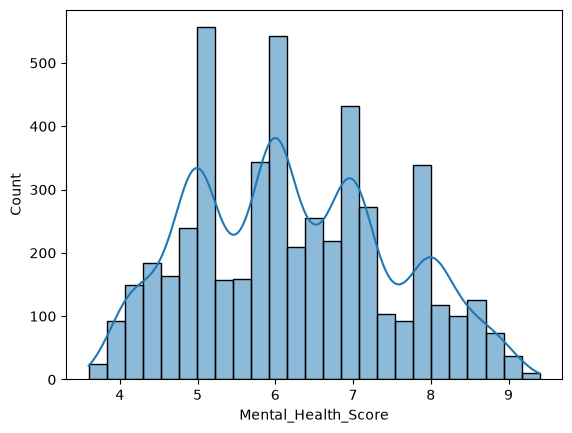

In [9]:
sns.histplot(df["Mental_Health_Score"],kde=True)

<Axes: >

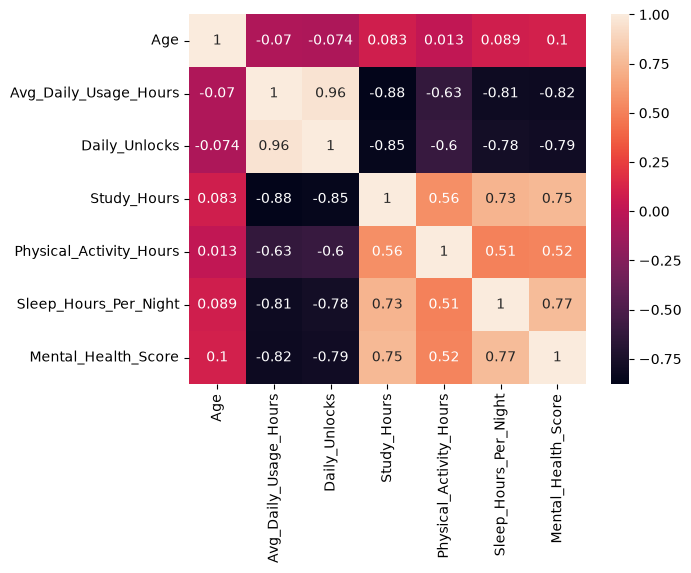

In [10]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [11]:
df["Stress_Level"].unique()

<ArrowStringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

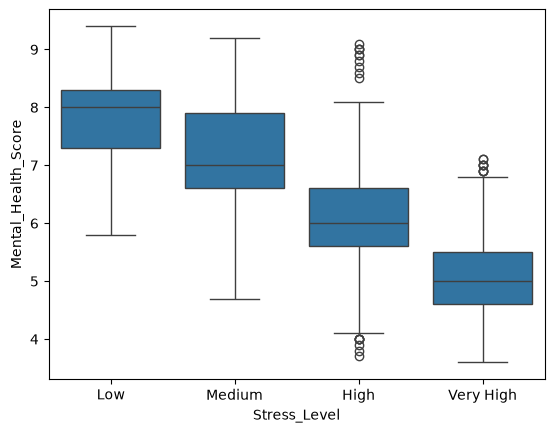

In [12]:
order=["Low","Medium","High","Very High"]
sns.boxplot(x = "Stress_Level" , y = "Mental_Health_Score" , data=df , order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

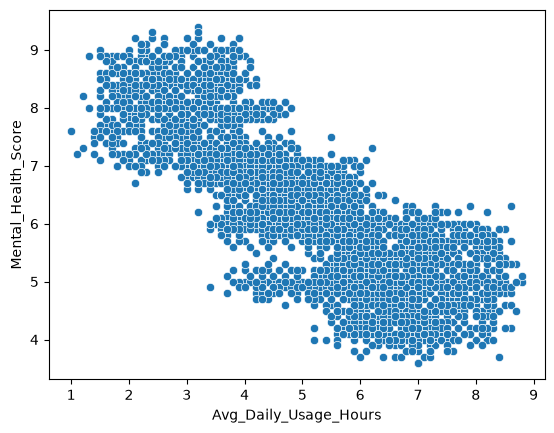

In [13]:
sns.scatterplot(x="Avg_Daily_Usage_Hours",y="Mental_Health_Score",data=df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

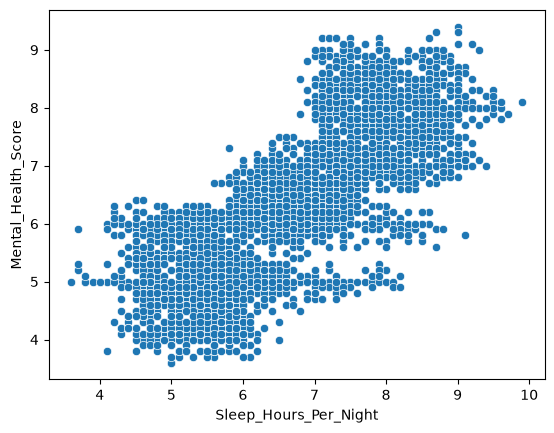

In [14]:
sns.scatterplot (x = 'Sleep_Hours_Per_Night', y = 'Mental_Health_Score' , data=df)

<Axes: xlabel='Physical_Activity_Hours', ylabel='Mental_Health_Score'>

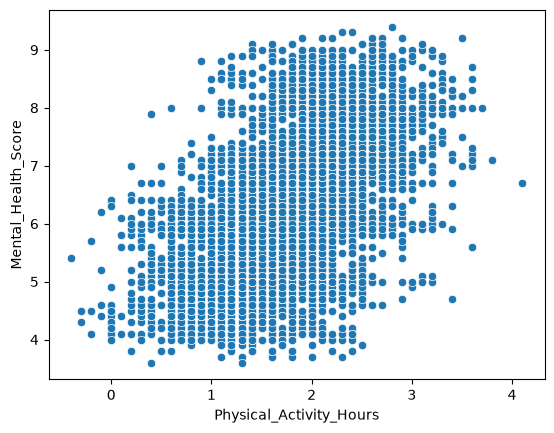

In [15]:
sns.scatterplot(x='Physical_Activity_Hours', y =  'Mental_Health_Score' , data = df)

<Axes: xlabel='Daily_Unlocks', ylabel='Mental_Health_Score'>

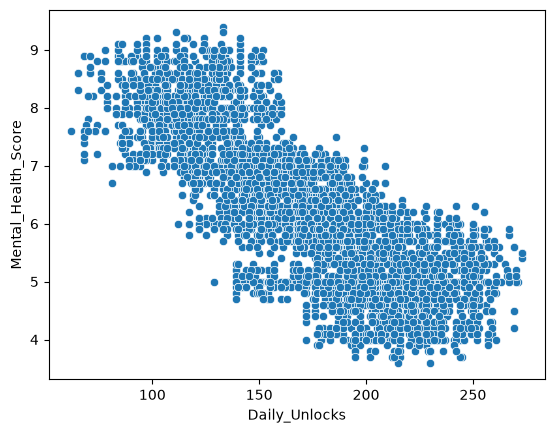

In [16]:
sns.scatterplot(x='Daily_Unlocks',y='Mental_Health_Score' , data=df)

In [17]:
platform_counts= df['Most_Used_Platform'].value_counts()
platform_counts


Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

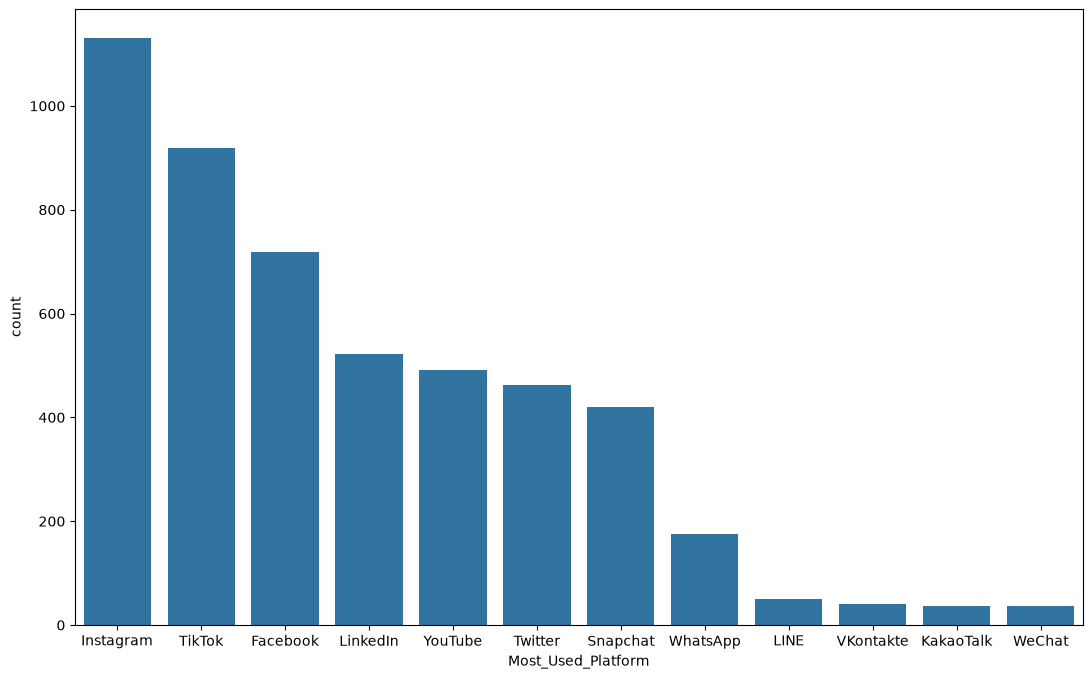

In [18]:
plt.figure(figsize=(13,8))
sns.countplot(x=df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)

In [19]:
num_features = df.select_dtypes(include ='number')
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR 

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [20]:
# to drop duplicates
df = df.drop_duplicates()

# converting negative or unrealistic value to realistic value
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=2)

In [21]:
num_cols = df.select_dtypes(include = 'number')
num_cols.skew()


Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    2.127728
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

In [22]:
top_countries=df['Country'].value_counts().index[:10].tolist()

In [23]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [24]:
df['Grouped_country'] = df['Country'].apply(group_countries)

In [25]:
df['Grouped_country'].value_counts()

Grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [26]:
from sklearn.model_selection import train_test_split

skwewd_col         = ['Study_Hours']
other_numeric_cols = ['Age' , 'Avg_Daily_Usage_Hours' , 'Daily_Unlocks' , 'Physical_Activity_Hours' , 'Sleep_Hours_Per_Night']
ordinal_col        = ['Stress_Level']
normal_col         = ['Gender' , 'Academic_Level' , 'Most_Used_Platform' , 'Purpose_Of_Use' , 'Grouped_country']

feature_col        = skwewd_col + other_numeric_cols + ordinal_col + normal_col

x = df[feature_col]
y = df['Mental_Health_Score']

x_train , x_test , y_train , y_test = train_test_split (x , y , test_size = 0.30 , random_state=42)


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer

# skewed feature

skew_pipeline = Pipeline(steps=[
    ('log_transform' , FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

# numeric features

plain_numeric_pipeline = Pipeline(steps = [
    ( 'scale',StandardScaler()) 

])

# ordinal
 
ordinal_pipeline = Pipeline(steps = [
    ('encode',OrdinalEncoder(categories = [['Low' , 'Medium' , 'High' , 'Very High']]))
])

# Norminal Feature
norminal_pipeline = Pipeline(steps = [
    ('encode' , OneHotEncoder(handle_unknown = 'ignore'))
])

# konsi_pipeline , konsa_feature
preprocessor = ColumnTransformer(transformers=[
    ('skewed_Pipeline', skew_pipeline, skwewd_col),
    ('plain_numeric', plain_numeric_pipeline, other_numeric_cols),
    ('ordinal_pipeline', ordinal_pipeline, ordinal_col),
    ('nominal_pipeline', norminal_pipeline, normal_col)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed_Pipeline', ...), ('plain_numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error
lr_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('regressor',LinearRegression())
])
lr_pipeline.fit(x_train ,y_train)
lr_preds = lr_pipeline.predict(x_test)
lr_preds_train = lr_pipeline.predict(x_train)

lr_r2_testing = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train , lr_preds_train)
lr_mae         = mean_absolute_error(y_test, lr_preds)

print(f"Accuracy of Training{lr_r2_training}")
print(f"Accuracy of Testing{lr_r2_testing}")
print(f"MAE {lr_mae}")



Accuracy of Training0.7238698626272256
Accuracy of Testing0.7401775533124819
MAE 0.5357999814788841


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps = [
    ("preprocessor" , preprocessor),
    ("random forest", RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(x_train , y_train)
rf_preds          = rf_pipeline.predict(x_test)
rf_preds_training = rf_pipeline.predict(x_train)

rf_r2_testing  = r2_score(y_test , rf_preds)
rf_r2_training = r2_score(y_train , rf_preds_training)
rf_mae         = mean_absolute_error(y_test ,rf_preds)

print(f"Accuracy of Training = {rf_r2_training}")
print(f"Accuracy of testing = {rf_r2_testing}")
print(f"MAE = {rf_mae}")

Accuracy of Training = 0.9810963564835845
Accuracy of testing = 0.879691008719339
MAE = 0.3417550111111112


In [30]:
from sklearn.model_selection import RandomizedSearchCV
param_grid ={
    "random forest__n_estimators"      : [100,200,300],
    "random forest__max_depth"         : [5,10,15],
    "random forest__min_samples_split" : [2,5,10],
    "random forest__min_samples_leaf"  : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator = rf_pipeline,
    param_distributions = param_grid,
    n_iter = 15,
    cv = 5,
    scoring = 'r2',
    random_state = 42 , 
    n_jobs = -1   # processor free
)

random_search.fit(x_train , y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'random forest__max_depth': [5, 10, ...], 'random forest__min_samples_leaf': [1, 2, ...], 'random forest__min_samples_split': [2, 5, ...], 'random forest__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dire

In [31]:
random_search.best_params_
{"random forest__n_estimators":200,
"random forest__min_samples_split":5,
"random forest__min_samples_leaf":2,
"random forest__max_depth":15}



 

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [ ]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds =rf_best_pipeline.predict(x_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test , rf_best_preds)}")


R2 Score for random forest after hyperparameter tuning 0.866676162296066
MAE Score for random forest after hyperparameter tuning 0.3650514144942044


In [33]:
from sklearn.metrics import mean_squared_error

# calculate rmse for linear regression
lr_rmse=np.sqrt(mean_squared_error(y_test , lr_preds))

# calculate rmse for default random forest
rf_rmse= np.sqrt(mean_squared_error(y_test , rf_preds))

# calculate rmse for tuned random forest
rf_tuned_preds          = random_search.best_estimator_.predict(x_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test , rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(x_train)
r2_tuned_training        = r2_score(y_train , rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test , rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test , rf_tuned_preds)

# create a DataFrame to consolidate results
results = pd.DataFrame({
    "model" : ['Linear Regression' , 'Random Forest (default)' , 'Random Forest (tuned)'],
    'R2' : [lr_r2_testing , rf_r2_testing , rf_tuned_r2],
    'Training R2' : [lr_r2_training , rf_r2_training , r2_tuned_training],
    'MAE' : [lr_mae , rf_mae, rf_tuned_mae],
    'RMSE' : [lr_rmse , rf_rmse , rf_tuned_rmse]

})

print(results)


                     model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.740178     0.723870  0.535800  0.675534
1  Random Forest (default)  0.879691     0.981096  0.341755  0.459682
2    Random Forest (tuned)  0.866676     0.953683  0.365051  0.483908


In [37]:
import joblib
joblib.dump(rf_pipeline,'Mental_Health_Model.pkl')


['Mental_Health_Model.pkl']

In [38]:
df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score',
 'Grouped_country']

In [41]:
df['Purpose_Of_Use'].unique()

<ArrowStringArray>
['Networking', 'Education', 'Entertainment', 'News']
Length: 4, dtype: str